In [15]:
from datasets import load_dataset
import pandas as pd

ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)

ds_level2 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-2_Missing_data_prediction/train_level2.csv",
    split="train",
)

df1 = ds_level1.to_pandas()
df2 = ds_level2.to_pandas()

print("Level 1 shape:", df1.shape)
print("Level 2 shape:", df2.shape)

print("\nFirst columns:", df1.columns[:5])
print("\nTop missing columns:")
print(df2.isna().mean().sort_values(ascending=False).head(10))


Level 1 shape: (494, 225)
Level 2 shape: (489, 225)

First columns: Index(['Date', 'Tenor : 1; Maturity : 0.0833333333333333',
       'Tenor : 2; Maturity : 0.0833333333333333',
       'Tenor : 3; Maturity : 0.0833333333333333',
       'Tenor : 4; Maturity : 0.0833333333333333'],
      dtype='str')

Top missing columns:
Date                        0.0
Tenor : 1; Maturity : 4     0.0
Tenor : 3; Maturity : 7     0.0
Tenor : 4; Maturity : 7     0.0
Tenor : 5; Maturity : 7     0.0
Tenor : 6; Maturity : 7     0.0
Tenor : 7; Maturity : 7     0.0
Tenor : 8; Maturity : 7     0.0
Tenor : 9; Maturity : 7     0.0
Tenor : 10; Maturity : 7    0.0
dtype: float64


In [16]:
df1["Date"] = pd.to_datetime(df1["Date"], dayfirst=True)
df1 = df1.sort_values("Date")

In [21]:
import re

print("Total columns:", len(df1.columns))
print(df1.columns[:20].tolist())

# show any columns containing "Price"
price_like = [c for c in df1.columns if "Price" in str(c)]
print("Price-like examples:", price_like[:20])

Total columns: 225
['Date', 'Tenor : 1; Maturity : 0.0833333333333333', 'Tenor : 2; Maturity : 0.0833333333333333', 'Tenor : 3; Maturity : 0.0833333333333333', 'Tenor : 4; Maturity : 0.0833333333333333', 'Tenor : 5; Maturity : 0.0833333333333333', 'Tenor : 6; Maturity : 0.0833333333333333', 'Tenor : 7; Maturity : 0.0833333333333333', 'Tenor : 8; Maturity : 0.0833333333333333', 'Tenor : 9; Maturity : 0.0833333333333333', 'Tenor : 10; Maturity : 0.0833333333333333', 'Tenor : 15; Maturity : 0.0833333333333333', 'Tenor : 20; Maturity : 0.0833333333333333', 'Tenor : 25; Maturity : 0.0833333333333333', 'Tenor : 30; Maturity : 0.0833333333333333', 'Tenor : 1; Maturity : 0.25', 'Tenor : 2; Maturity : 0.25', 'Tenor : 3; Maturity : 0.25', 'Tenor : 4; Maturity : 0.25', 'Tenor : 5; Maturity : 0.25']
Price-like examples: []


In [22]:
#Let's try visualizing the 'Price' column over time first to see how it looks like
import matplotlib.pyplot as plt
import numpy as np
import re

surface_cols = [col for col in df1.columns if col != "Date"]

tenors = []
marturities = []

for col in surface_cols:
    t = float(re.search(r"Tenor : (.*?);", col).group(1))
    m = float(re.search(r"Maturity : (.*)", col).group(1))
    tenors.append(t)
    marturities.append(m)

tenors = np.array(tenors)
marturities = np.array(marturities)

In [23]:
row0 = df1.iloc[0]
values = row0[surface_cols].values

print("len(surface_cols) =", len(surface_cols))
print("values.shape      =", values.shape)

print("len(tenors)       =", len(tenors))
print("len(marturities)  =", len(marturities))

print("tenors[:5]        =", tenors[:5] if len(tenors)>0 else tenors)
print("marturities[:5]   =", marturities[:5] if len(marturities)>0 else marturities)

print("values[:10]       =", values[:10])

len(surface_cols) = 224
values.shape      = (224,)
len(tenors)       = 224
len(marturities)  = 224
tenors[:5]        = [1. 2. 3. 4. 5.]
marturities[:5]   = [0.08333333 0.08333333 0.08333333 0.08333333 0.08333333]
values[:10]       = [np.float64(0.0285652484701604) np.float64(0.0386996591094758)
 np.float64(0.0401265446992372) np.float64(0.0407619419194563)
 np.float64(0.0404662555776512) np.float64(0.0389526887052479)
 np.float64(0.0375534712632436) np.float64(0.0367681209429944)
 np.float64(0.0366455306250858) np.float64(0.0355946112670686)]


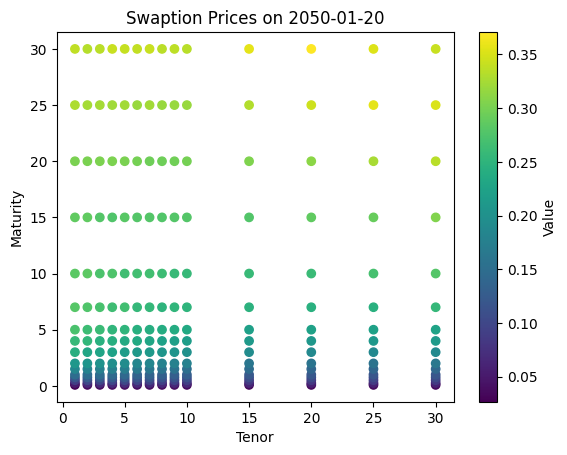

In [ ]:
#Try to pick on data
#Plot 1: Swaption price surface for the one date

row0 = df1.iloc[13]
values = row0[surface_cols].values

plt.figure()
plt.scatter(tenors, marturities, c=values, cmap="viridis")
plt.xlabel("Tenor")
plt.ylabel("Maturity")

plt.title("Swaption Prices on " + row0["Date"].strftime("%Y-%m-%d"))
plt.colorbar(label="Value")
plt.show()

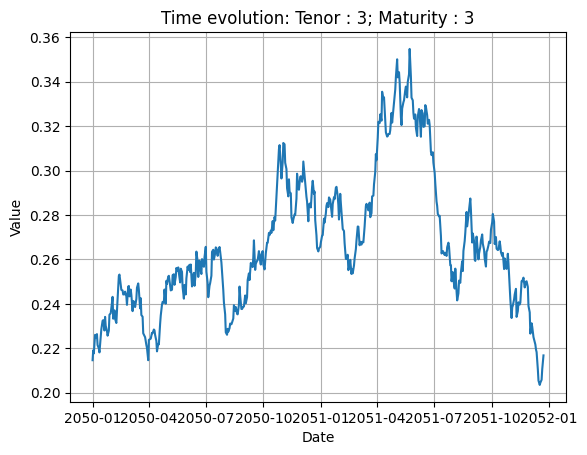

In [30]:
#Plot 2: Time series of a specific swaption price
col = surface_cols[100]

plt.figure()
plt.plot(df1["Date"], df1[col])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title(f"Time evolution: {col}")
plt.grid()
plt.show()


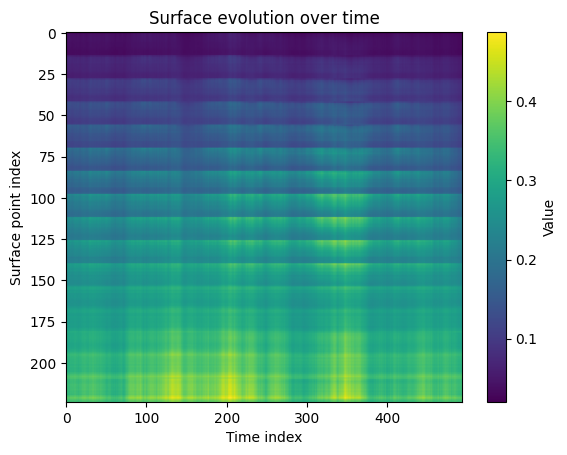

In [31]:
#Heatmap across time for a specific maturity
X = df1[surface_cols].values

plt.figure()
plt.imshow(X.T, aspect="auto")
plt.colorbar(label="Value")
plt.xlabel("Time index")
plt.ylabel("Surface point index")
plt.title("Surface evolution over time")
plt.show()

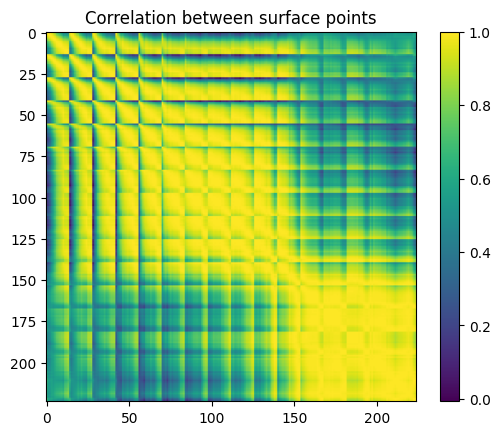

In [33]:
#Correlation between surface points
corr = np.corrcoef(X.T)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation between surface points")
plt.show()

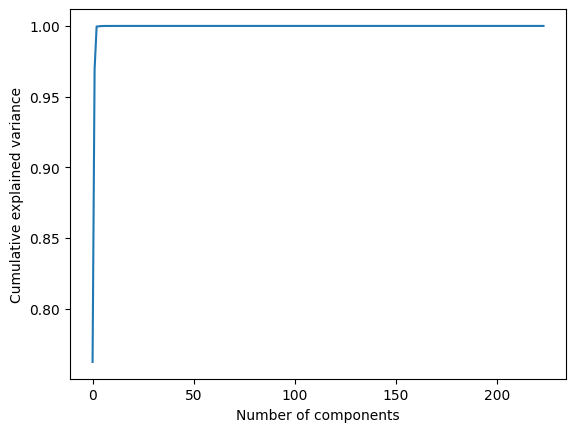

In [34]:
#Check rank structure
from sklearn.decomposition import PCA

X = df1[surface_cols].values
pca = PCA()
pca.fit(X)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()


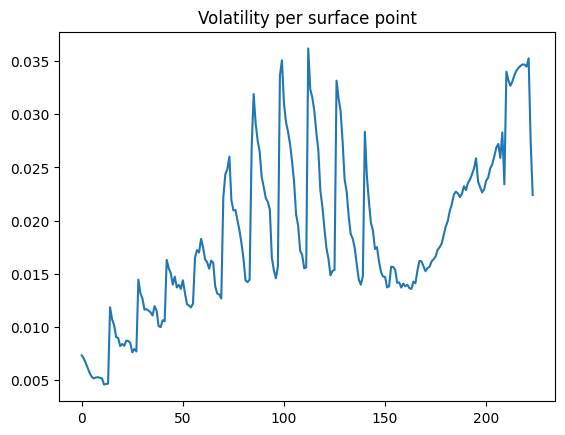

In [35]:
#Plot variance per surface point
plt.plot(X.std(axis=0))
plt.title("Volatility per surface point")
plt.show()

<Axes: >

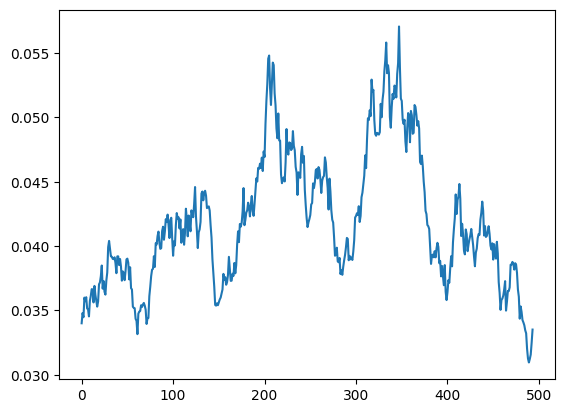

In [41]:
df1[surface_cols[10]].plot()

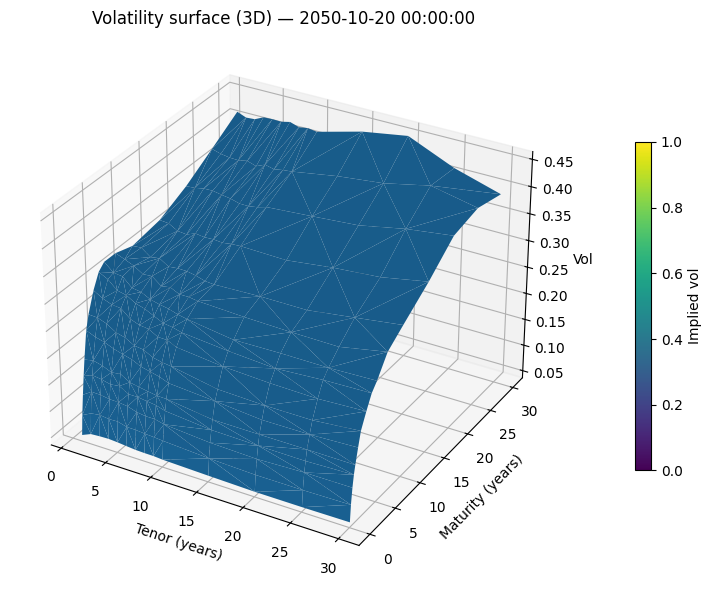

In [45]:
#Plot the voltaility of the first surface point over time
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.tri as mtri

def plot_vol_surface_3d(df, date_idx):
    row = df.iloc[date_idx]
    z = row[surface_cols].astype(float).to_numpy()

    tri = mtri.Triangulation(tenors, marturities)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_trisurf(tri, z, linewidth=0.2, antialiased=True)

    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="Implied vol")
    ax.set_xlabel("Tenor (years)")
    ax.set_ylabel("Maturity (years)")
    ax.set_zlabel("Vol")
    ax.set_title(f"Volatility surface (3D) — {row['Date']}")
    plt.tight_layout()
    plt.show()

plot_vol_surface_3d(df1, date_idx=200)

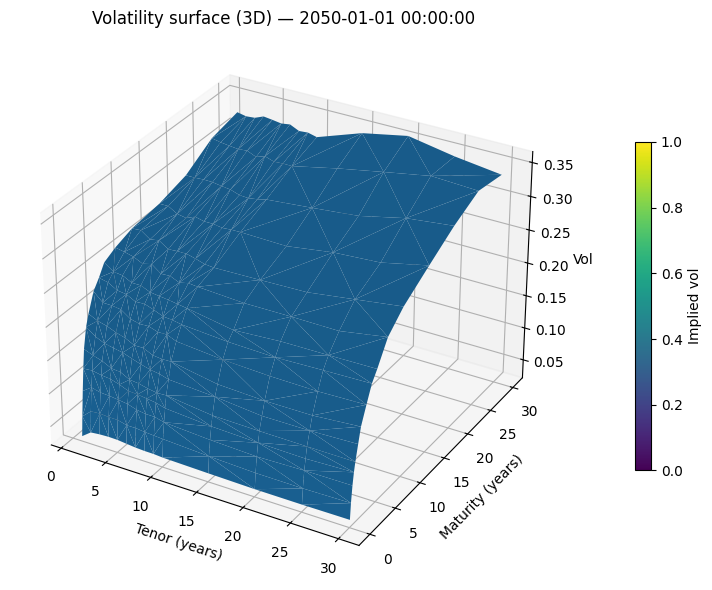

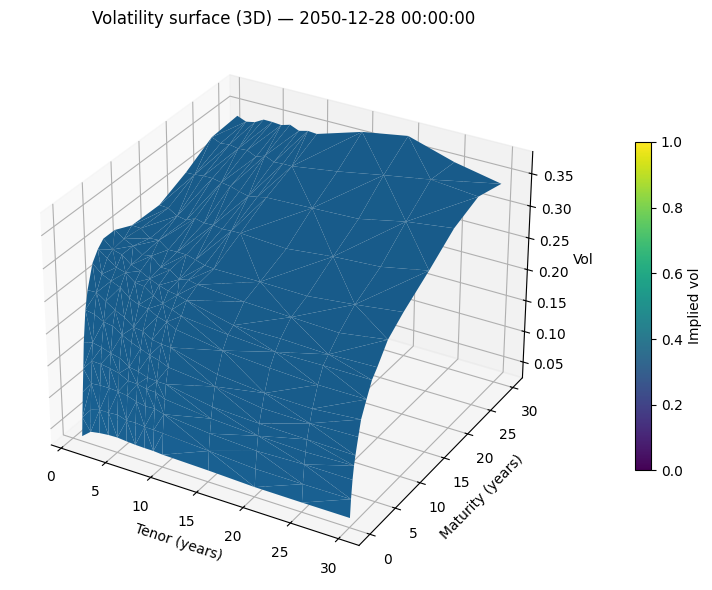

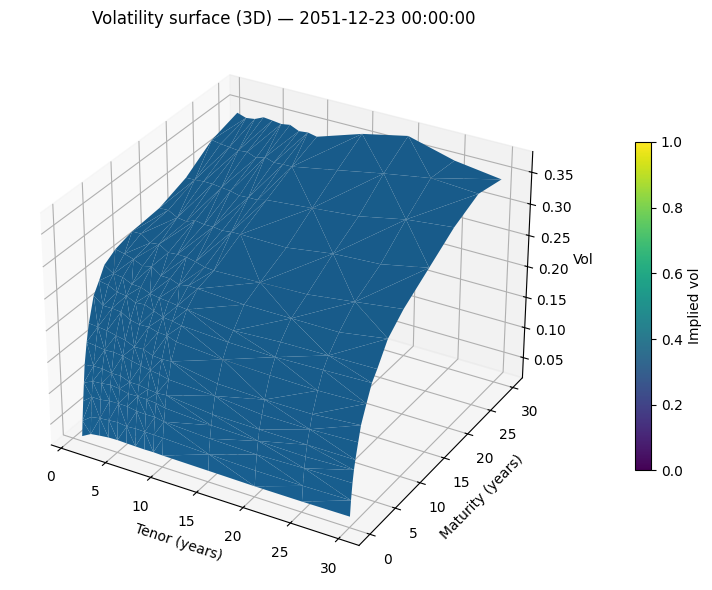

In [47]:
for idx in [0, len(df1)//2, len(df1)-1]:
    plot_vol_surface_3d(df1, date_idx=idx)